In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

### Define paths

In [21]:
ROOT = Path().cwd().parent
data_path = Path(ROOT/ "data")

train_labels_path = data_path / "train_set_age_labels.csv"
valid_labels_path = data_path / "valid_set_age_labels.csv"
test_labels_path = data_path / "test_set_age_labels.csv"

train_files_folder = data_path / "train"
valid_files_folder = data_path / "valid"
test_files_folder = data_path / "test"

### Load data

In [22]:
train_labels_set = pd.read_csv(train_labels_path)
valid_labels_set = pd.read_csv(valid_labels_path)
test_labels_set = pd.read_csv(test_labels_path)

### Check data consistency
Does every sample have video, text and image data?

In [23]:
train_labels_set["FileName"] = train_labels_set["VideoName"].apply(lambda x: Path(x).stem)
valid_labels_set["FileName"] = valid_labels_set["VideoName"].apply(lambda x: Path(x).stem)
test_labels_set["FileName"]  = test_labels_set["VideoName"].apply(lambda x: Path(x).stem)

label_stems = {
    "train": set(train_labels_set["FileName"].unique()),
    "valid": set(valid_labels_set["FileName"].unique()),
    "test": set(test_labels_set["FileName"].unique()),
}

data_folders = {
    "train": train_files_folder,
    "valid": valid_files_folder,
    "test": test_files_folder,
}

extensions = [".jpg", ".wav", ".pkl"]
results = {}

for split in ["train", "valid", "test"]:
    all_stems = {}
    
    for extension in extensions:
        files = list(data_folders[split].glob(f"*/*{extension}"))
        all_stems[extension] = set(f.stem for f in files)
    
    common_stems = set.intersection(*all_stems.values())
    label_set = label_stems[split]
    
    valid_samples = common_stems & label_set
    missing_modalities = label_set - common_stems
    
    results[split] = {
        "all_stems": all_stems,
        "common_stems": common_stems,
        "valid_samples": valid_samples,
        "missing_modalities": missing_modalities,
    }
    
    print(f"\n--- {split.upper()} ---")
    print(f"Labeled samples: {len(label_set)}")
    print(f"Samples with all modalities: {len(common_stems)}")
    print(f"Usable labeled samples: {len(valid_samples)}")
    print(f"Labeled samples missing at least one modality: {len(missing_modalities)}")
    
    for ext, stems in all_stems.items():
        missing = label_set - stems
        print(f"{ext}: missing {len(missing)} files")


--- TRAIN ---
Labeled samples: 6006
Samples with all modalities: 6006
Usable labeled samples: 6006
Labeled samples missing at least one modality: 0
.jpg: missing 0 files
.wav: missing 0 files
.pkl: missing 0 files

--- VALID ---
Labeled samples: 2019
Samples with all modalities: 2019
Usable labeled samples: 2019
Labeled samples missing at least one modality: 0
.jpg: missing 0 files
.wav: missing 0 files
.pkl: missing 0 files

--- TEST ---
Labeled samples: 1975
Samples with all modalities: 1975
Usable labeled samples: 1975
Labeled samples missing at least one modality: 0
.jpg: missing 0 files
.wav: missing 0 files
.pkl: missing 0 files


### Missing Group Analysis
Does every group (Ethnicity+AgeGroup+Gender) have sample representation?

In [24]:
# Define label sets for the three splits
label_folders = {
    "train": train_labels_set,
    "valid": valid_labels_set,
    "test": test_labels_set
}

In [25]:
def find_missing_categories(label_folder):
    all_ethnicities = label_folder["Ethnicity"].unique()
    all_genders = label_folder["Gender"].unique()
    all_agegroups = label_folder["AgeGroup"].unique()

    full_index = pd.MultiIndex.from_product(
        [all_ethnicities, all_genders, all_agegroups],
        names=["Ethnicity", "Gender", "AgeGroup"]
    )

    counts = (
        label_folder
        .groupby(["Ethnicity", "Gender", "AgeGroup"])
        .size()
        .reindex(full_index, fill_value=0)
    )

    missing = counts[counts == 0]
    return missing.reset_index(name="count")

In [26]:
for split in ["train", "valid", "test"]:
    label_folder = label_folders[split]
    missing_df = find_missing_categories(label_folder)

num_missing = len(missing_df)
print(f"Missing {num_missing} groups.")
missing_df

Missing 14 groups.


,Ethnicity,Gender,AgeGroup,count
0,1,2,1,0
1,1,2,6,0
2,1,2,7,0
3,1,1,1,0
4,1,1,5,0
5,1,1,6,0
6,1,1,7,0
7,3,2,1,0
8,3,2,2,0
9,3,2,6,0


### Age Distribution across Demographic Groups

In [27]:
def bar_plot(map, vars = ["AgeGroup","Gender"]):

    for split in ["train", "valid", "test"]:
        labels = label_folders[split]
        
        # Count per AgeGroup and Gender
        counts = (
            labels
            .groupby(vars)
            .size()
            .unstack(fill_value=0)
            .rename(columns=map)
            .sort_index()
        )

        # Normalize 
        counts_norm = counts.div(counts.sum(axis=1), axis=0)
    
        # Plot side by side
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
        
        # RAW
        counts.plot(
            kind="bar",
            ax=axes[0]
        )
        axes[0].set_title("RAW Counts")
        axes[0].set_xlabel(vars[0])
        axes[0].set_ylabel("Count")
        axes[0].legend(title=vars[1])
        axes[0].grid(axis="y", alpha=0.2)
        
        # NORMALIZED
        counts_norm.plot(
            kind="bar",
            ax=axes[1]
        )
        axes[1].set_title("Normalized (Proportion)")
        axes[1].set_xlabel(vars[0])
        axes[1].set_ylabel("Proportion")
        axes[1].legend(title=vars[1])
        axes[1].grid(axis="y", alpha=0.2)
        
        fig.suptitle(f"{vars[0]} vs {vars[1]} ({split})")
        plt.tight_layout()
        plt.show()

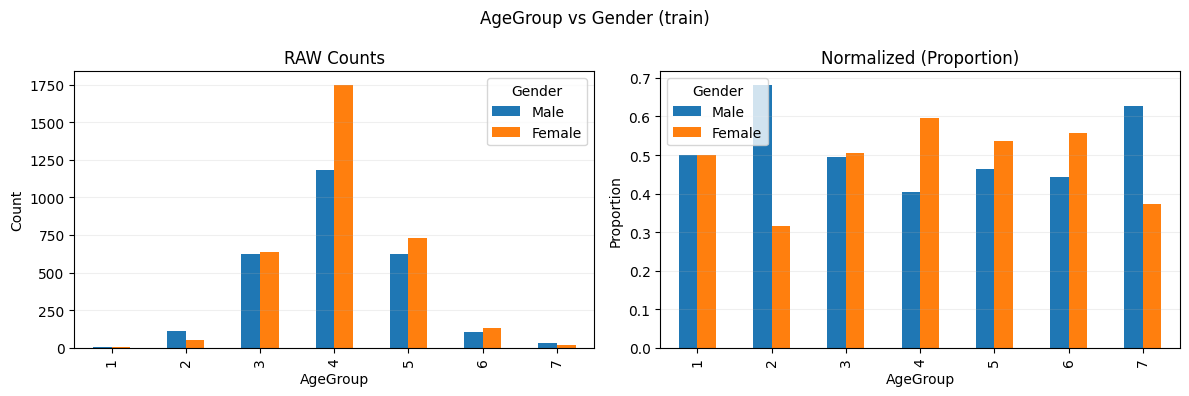

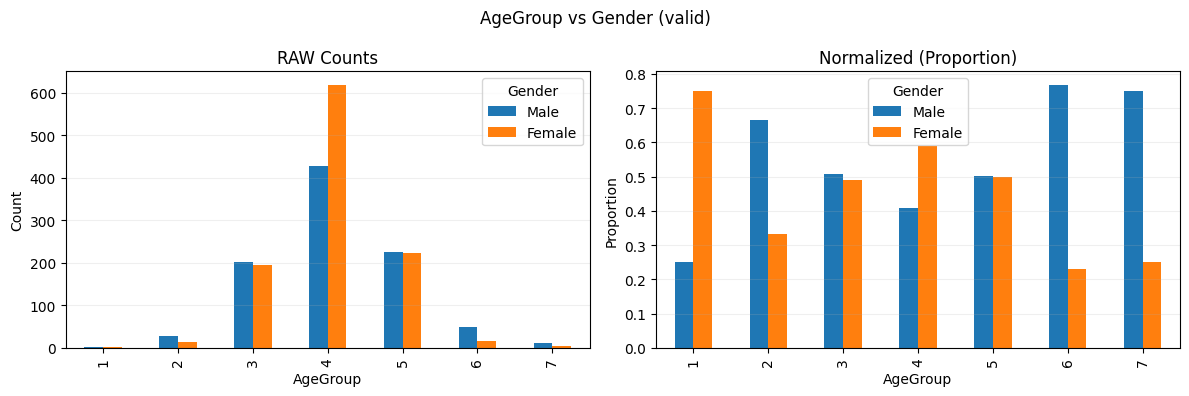

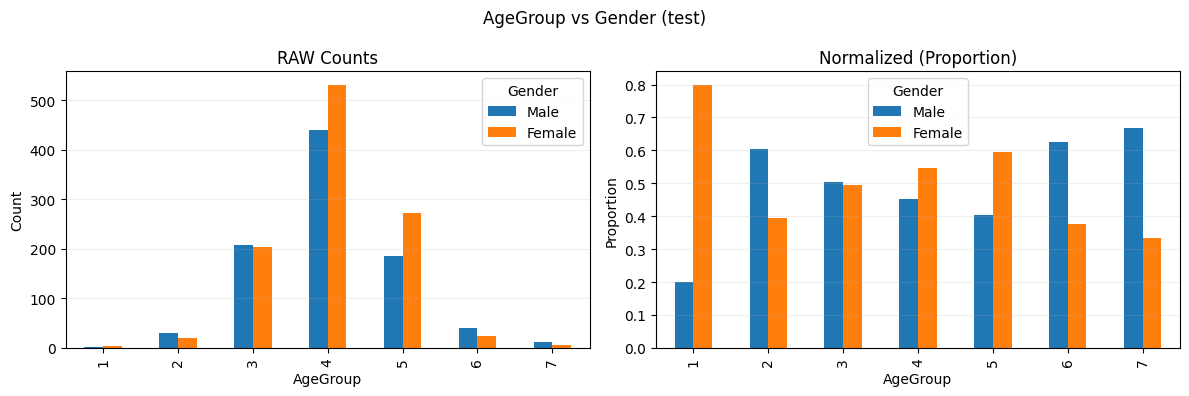

In [28]:
# Age vs Gender
gender_map = {
    1: "Male",
    2: "Female"
}

bar_plot(gender_map, ["AgeGroup", "Gender"])

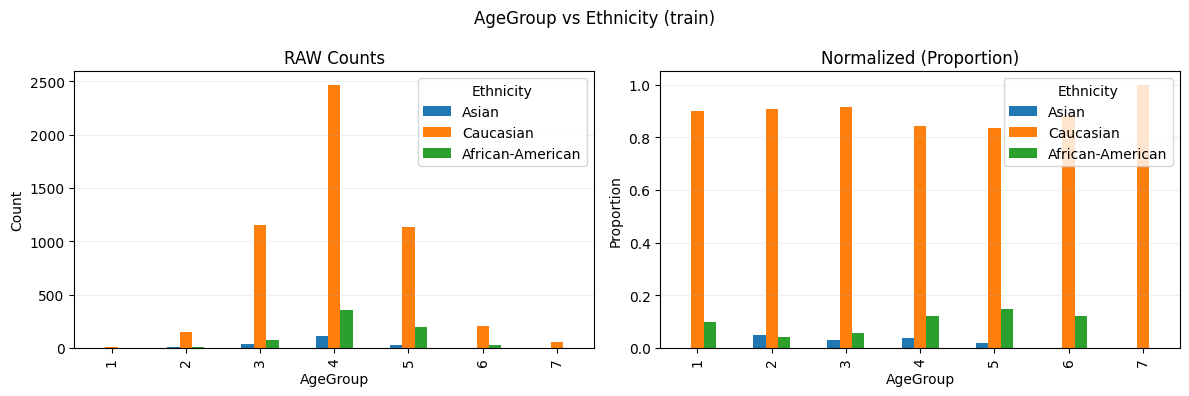

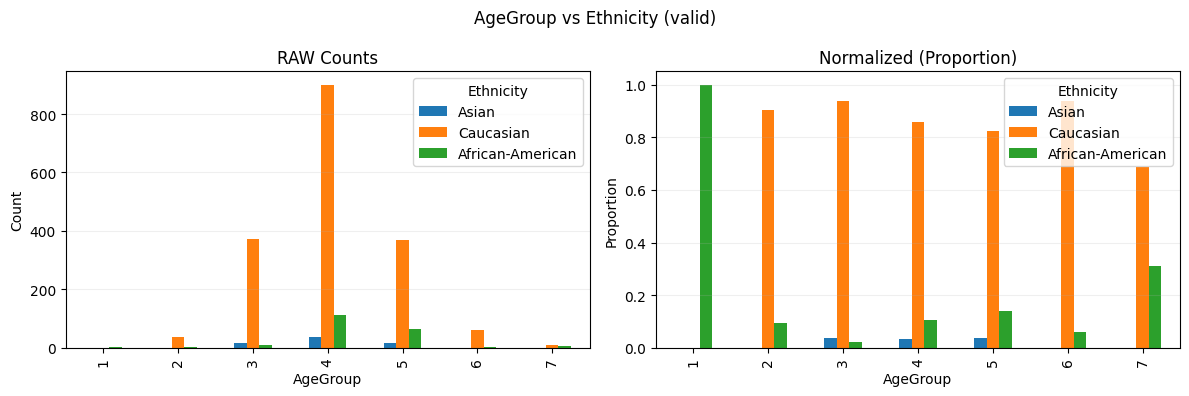

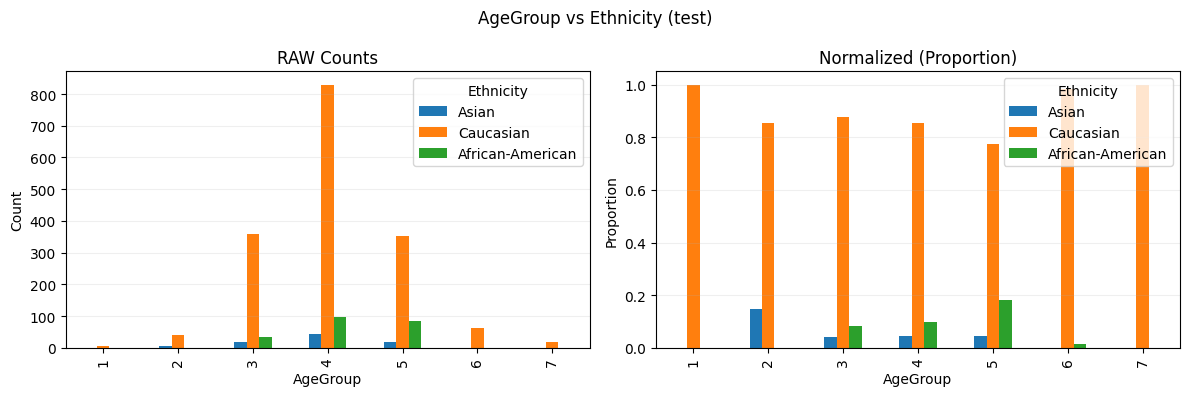

In [29]:
# Age vs Ethnicity
ethnicity_map = { 
    1: "Asian",
    2: "Caucasian", 
    3: "African-American" 
}

bar_plot(ethnicity_map, ["AgeGroup", "Ethnicity"])

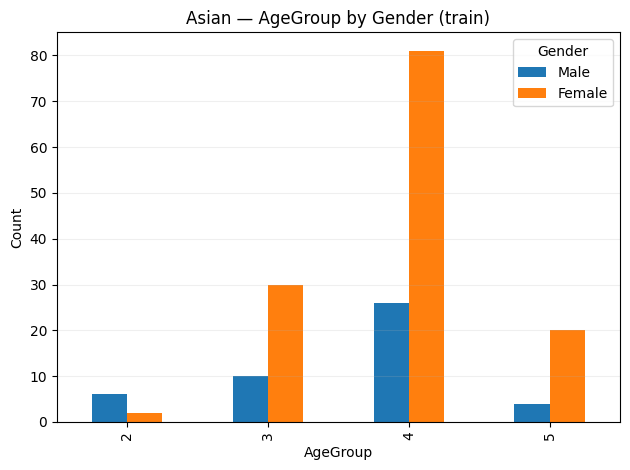

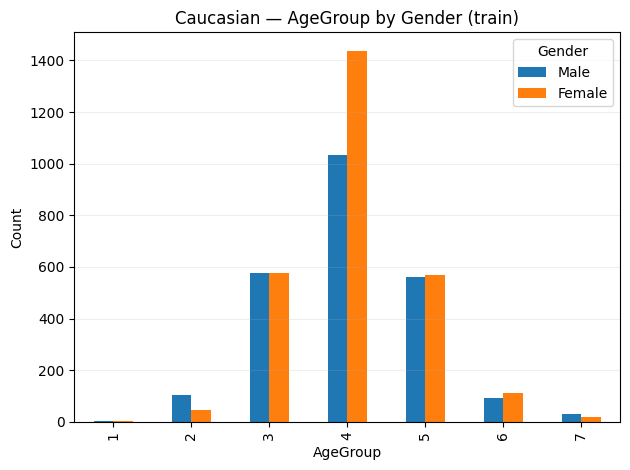

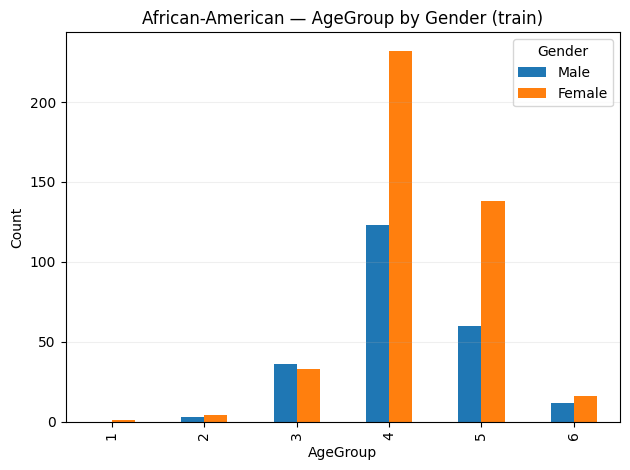

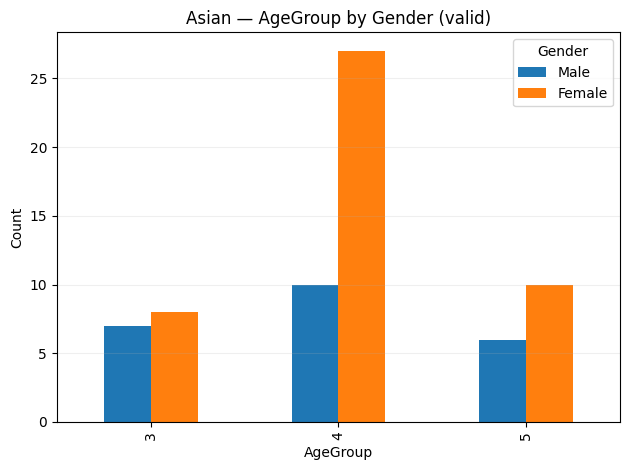

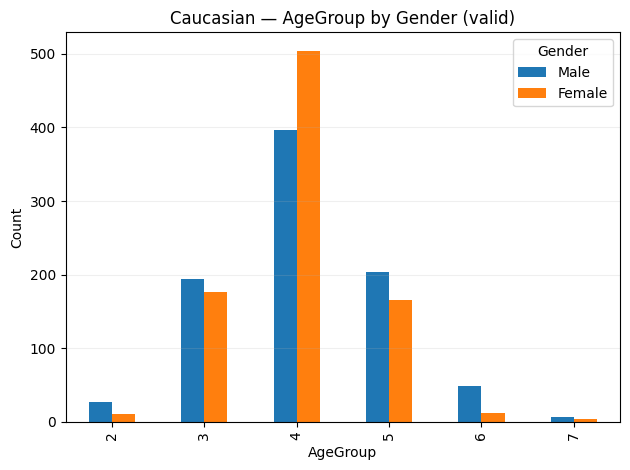

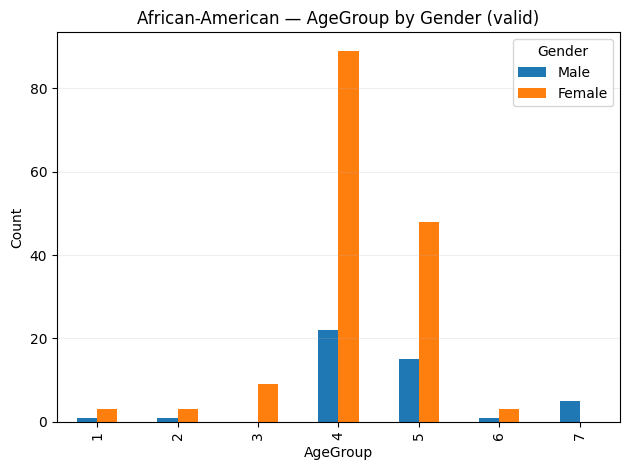

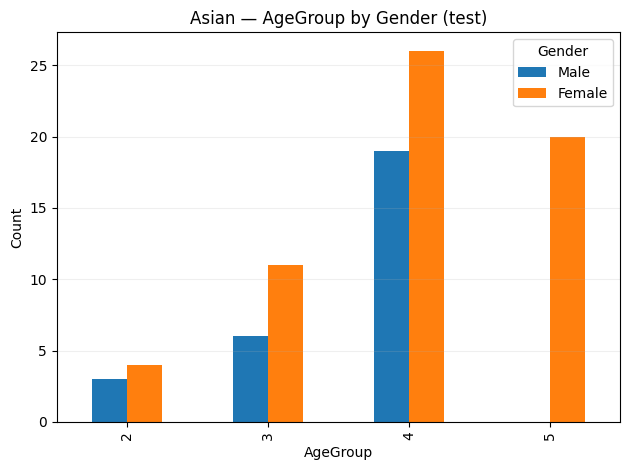

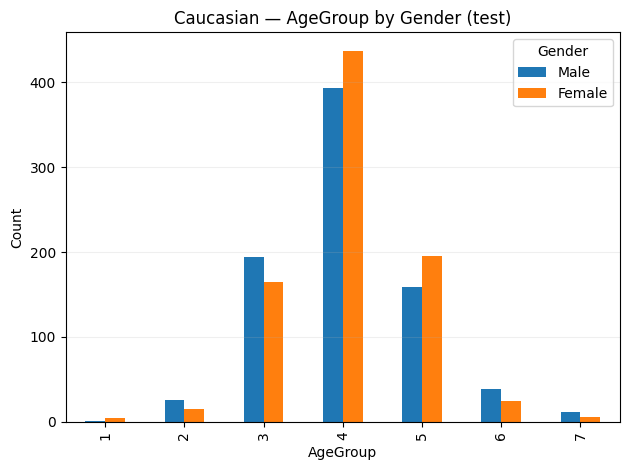

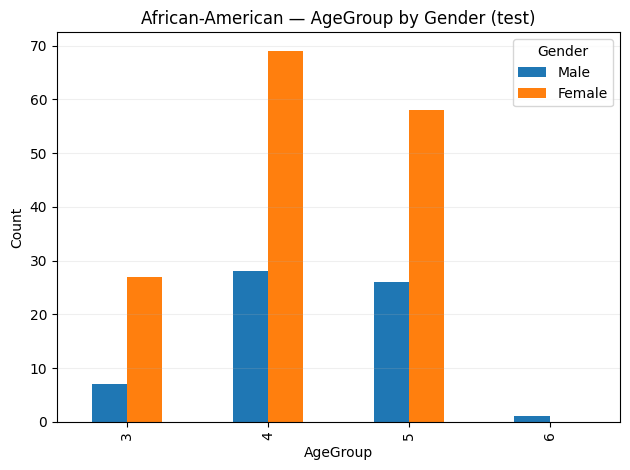

In [30]:
for split in ["train", "valid", "test"]:
    labels = label_folders[split]
    
    for ethnicity, eth_group in labels.groupby("Ethnicity"):
        eth_name = ethnicity_map[ethnicity]
        
        # Count samples
        counts = (
            eth_group
            .groupby(["AgeGroup", "Gender"])
            .size()
            .unstack(fill_value=0)
            .sort_index()
        )
        
        # Plot
        counts = counts.rename(columns=gender_map)
        counts.plot(kind="bar")
        
        plt.title(f"{eth_name} — AgeGroup by Gender ({split})")
        plt.xlabel("AgeGroup")
        plt.ylabel("Count")
        plt.legend(title="Gender")
        plt.grid(axis="y", alpha=0.2)
        plt.tight_layout()
        plt.show()

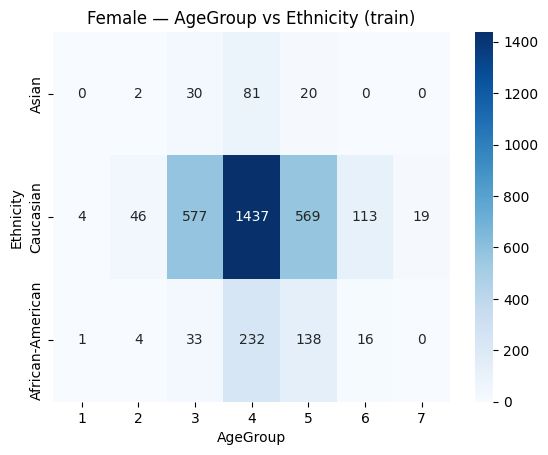

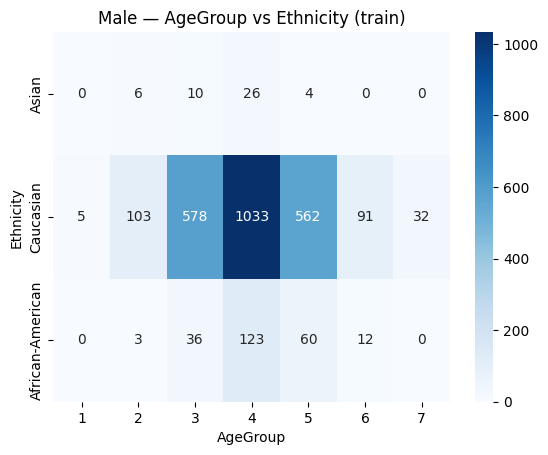

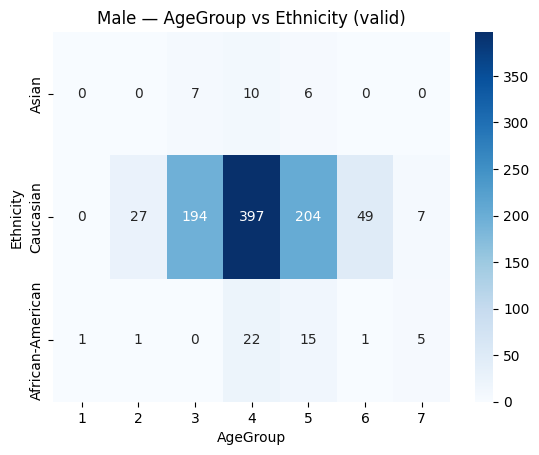

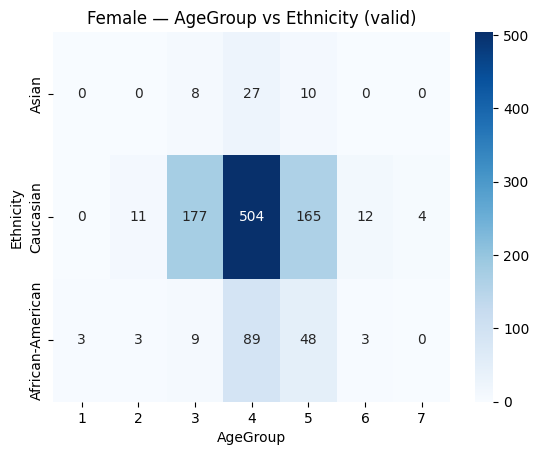

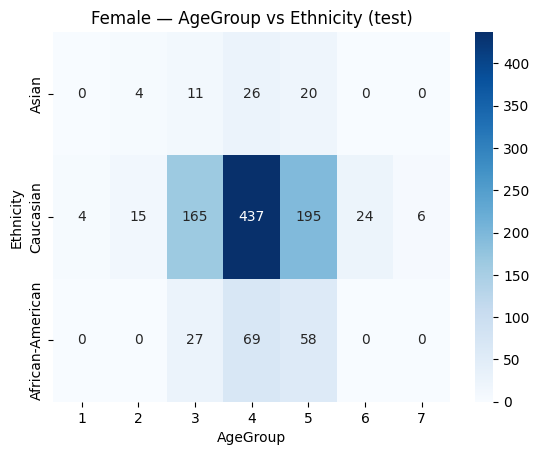

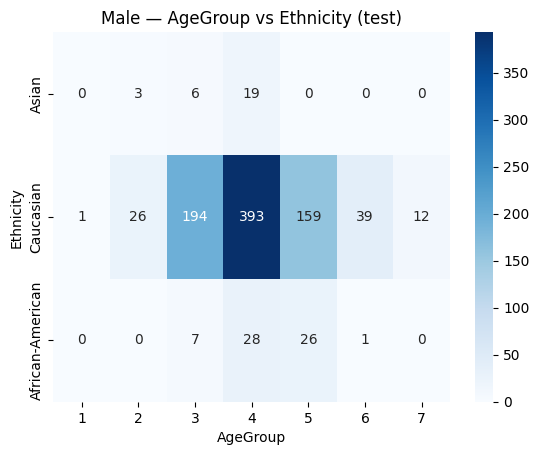

In [31]:
for split in ["train", "valid", "test"]:
    labels = label_folders[split]
    
    # Create pivot table
    pivot = labels.groupby(["Ethnicity", "AgeGroup", "Gender"]).size().reset_index(name="count")
    
    for gender in labels["Gender"].unique():
        plt.figure()
        
        data = pivot[pivot["Gender"] == gender]
        table = data.pivot(index="Ethnicity", columns="AgeGroup", values="count").fillna(0)
        table = table.rename(index=ethnicity_map)
        
        sns.heatmap(table, annot=True, fmt=".0f", cmap="Blues")
        
        plt.title(f"{gender_map[gender]} — AgeGroup vs Ethnicity ({split})")
        plt.xlabel("AgeGroup")
        plt.ylabel("Ethnicity")
        plt.show()

### Get some numbers

In [32]:
def missing_percentage(label_folder):
    all_ethnicities = label_folder["Ethnicity"].unique()
    all_genders = label_folder["Gender"].unique()
    all_agegroups = label_folder["AgeGroup"].unique()

    total_combinations = (
        len(all_ethnicities) *
        len(all_genders) *
        len(all_agegroups)
    )

    missing = find_missing_categories(label_folder)
    num_missing = len(missing)

    return {
        "missing_%": 100 * num_missing / total_combinations,
        "num_missing": num_missing,
        "total_combinations": total_combinations
    }

In [33]:
def imbalance_ratio(label_folder):
    counts = (
        label_folder
        .groupby(["Ethnicity", "Gender", "AgeGroup"])
        .size()
    )
    
    return counts.max() / counts.min()

In [34]:
def imbalance_cv(label_folder):
    counts = (
        label_folder
        .groupby(["Ethnicity", "Gender", "AgeGroup"])
        .size()
    )
    
    return counts.std() / counts.mean()

In [35]:
def most_imbalanced_groups(label_folder, top_k=5):
    counts = (
        label_folder
        .groupby(["Ethnicity", "Gender", "AgeGroup"])
        .size()
        .reset_index(name="count")
    )
    
    return counts.sort_values("count").head(top_k), counts.sort_values("count", ascending=False).head(top_k)

In [36]:
def gender_imbalance(label_folder):
    counts = (
        label_folder
        .groupby(["AgeGroup", "Gender"])
        .size()
        .unstack(fill_value=0)
    )
    
    ratio = counts.max(axis=1) / counts.min(axis=1)
    
    return ratio

In [37]:
def ethnicity_distribution(label_folder):
    counts = label_folder["Ethnicity"].value_counts(normalize=True)
    return counts

In [38]:
for split in ["train", "valid", "test"]:
    labels = label_folders[split]
    
    print(f"\n--- {split.upper()} ---")
    
    # Missing
    miss = missing_percentage(labels)
    print(f"Missing groups: {miss['missing_%']:.2f}% ({miss['num_missing']}/{miss['total_combinations']})")
    
    # Imbalance
    print(f"Imbalance ratio (max/min): {imbalance_ratio(labels):.2f}")
    print(f"Imbalance CV: {imbalance_cv(labels):.2f}")
    
    # Gender imbalance
    print("\nGender imbalance per AgeGroup:")
    print(gender_imbalance(labels))
    
    # Ethnicity distribution
    print("\nEthnicity distribution:")
    print(ethnicity_distribution(labels))


--- TRAIN ---
Missing groups: 21.43% (9/42)
Imbalance ratio (max/min): 1437.00
Imbalance CV: 1.81

Gender imbalance per AgeGroup:
AgeGroup
1    1.000000
2    2.153846
3    1.025641
4    1.480541
5    1.161342
6    1.252427
7    1.684211
dtype: float64

Ethnicity distribution:
Ethnicity
2    0.860639
3    0.109557
1    0.029804
Name: proportion, dtype: float64

--- VALID ---
Missing groups: 28.57% (12/42)
Imbalance ratio (max/min): 504.00
Imbalance CV: 1.81

Gender imbalance per AgeGroup:
AgeGroup
1    3.000000
2    2.000000
3    1.036082
4    1.445221
5    1.008969
6    3.333333
7    3.000000
dtype: float64

Ethnicity distribution:
Ethnicity
2    0.867261
3    0.099059
1    0.033680
Name: proportion, dtype: float64

--- TEST ---
Missing groups: 33.33% (14/42)
Imbalance ratio (max/min): 437.00
Imbalance CV: 1.61

Gender imbalance per AgeGroup:
AgeGroup
1    4.000000
2    1.526316
3    1.019704
4    1.209091
5    1.475676
6    1.666667
7    2.000000
dtype: float64

Ethnicity distributio